In [ ]:
# Phase 1: Data Understanding

import pandas as pd

# Load dataset (replace with your actual file path)
df = pd.read_csv("upi_fraud_india_dataset.csv")

# Inspect first few rows
print("Sample records:")
print(df.head())

# Dataset shape
print("\nNumber of transactions:", len(df))

# Check feature definitions (columns)
print("\nColumns in dataset:")
print(df.columns)

# Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()
print("\nDataset shape after removing duplicates:", df.shape)

# Basic info
print("\nDataset info:")
print(df.info())

# Study distributions
print("\nTransaction amount distribution:")
print(df['amount_inr'].describe())
# Suspicious transactions percentage (assuming 'isFraud' column exists)
if 'isFraud' in df.columns:
    fraud_rate = df['isFraud'].mean() * 100
    print(f"\nPercentage of suspicious transactions: {fraud_rate:.2f}%")

In [94]:
#How many transactions exist? 
# --- Total transactions ---
total_transactions = len(df)
print("Total transactions:", total_transactions)

# --- Suspicious transactions percentage ---
# Assuming 'is_fraud' column exists (1 = fraud, 0 = normal)
suspicious_percentage = df['is_fraud'].mean() * 100
print(f"Suspicious transactions percentage: {suspicious_percentage:.2f}%")


Total transactions: 1000
Suspicious transactions percentage: 100.00%


In [9]:
# Phase 2: Descriptive Statistical Analysis

import pandas as pd

# Load dataset
df = pd.read_csv("upi_fraud_india_dataset.csv")

# --- Transaction Amount Analysis ---
print("\nTransaction Amount Statistics:")
print(df['amount_inr'].describe())  # mean, std, min, max, quartiles

print("\nMedian Transaction Amount:", df['amount_inr'].median())
print("Standard Deviation of Amount:", df['amount_inr'].std())

# Percentiles
print("\n90th Percentile:", df['amount_inr'].quantile(0.90))
print("95th Percentile:", df['amount_inr'].quantile(0.95))
print("99th Percentile:", df['amount_inr'].quantile(0.99))

# --- Daily Transaction Frequency ---
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Count transactions per day
daily_counts = df.groupby(df['date'].dt.date).size()

print("\nAverage Daily Transaction Frequency:", daily_counts.mean())
print("Max Transactions in a Day:", daily_counts.max())
print("Min Transactions in a Day:", daily_counts.min())

# --- Skewness Check ---
print("\nSkewness of Transaction Amounts:", df['amount_inr'].skew())



Transaction Amount Statistics:
count      1000.000000
mean      15911.454000
std       36184.658706
min         500.000000
25%        2387.500000
50%        5300.000000
75%       14725.000000
max      495050.000000
Name: amount_inr, dtype: float64

Median Transaction Amount: 5300.0
Standard Deviation of Amount: 36184.65870552765

90th Percentile: 39765.0
95th Percentile: 68394.99999999996
99th Percentile: 138738.99999999933

Average Daily Transaction Frequency: 1.7953321364452424
Max Transactions in a Day: 6
Min Transactions in a Day: 1

Skewness of Transaction Amounts: 7.052797911622201


In [96]:
#QUESTIONS
# --- 1. Average Transaction Amount ---
avg_amount = df['amount_inr'].mean()
print("Average Transaction Amount (INR):", avg_amount)

# --- 2. Average Daily Transaction Frequency ---
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Count transactions per day
daily_counts = df.groupby(df['date'].dt.date).size()

# Average daily frequency
avg_daily_freq = daily_counts.mean()
print("Average Daily Transaction Frequency:", avg_daily_freq)

# --- 3. Skewness of Transaction Amount Distribution ---
skewness = df['amount_inr'].skew()
print("Skewness of Transaction Amounts:", skewness)

if skewness > 1:
    print("Distribution is heavily positively skewed (long right tail).")
elif skewness < -1:
    print("Distribution is heavily negatively skewed (long left tail).")
else:
    print("Distribution is approximately symmetric.")


Average Transaction Amount (INR): 15911.454
Average Daily Transaction Frequency: 1.7953321364452424
Skewness of Transaction Amounts: 7.052797911622201
Distribution is heavily positively skewed (long right tail).


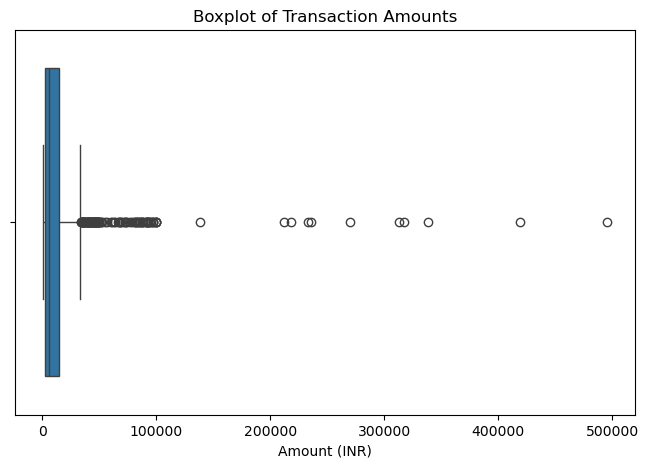

In [ ]:
#Phase 3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("upi_fraud_india_dataset.csv")

# Boxplot for transaction amounts
plt.figure(figsize=(8,5))
sns.boxplot(x=df['amount_inr'])
plt.title("Boxplot of Transaction Amounts")
plt.xlabel("Amount (INR)")
plt.show()

In [13]:
# Calculate Q1 and Q3
Q1 = df['amount_inr'].quantile(0.25)
Q3 = df['amount_inr'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers_iqr = df[(df['amount_inr'] < lower_bound) | (df['amount_inr'] > upper_bound)]

print("Number of outliers detected using IQR:", len(outliers_iqr))
print(outliers_iqr[['transaction_id','amount_inr','fraud_type']].head())


Number of outliers detected using IQR: 120
     transaction_id  amount_inr    fraud_type
9   TXN108901504899       87350  QR Code Swap
20  TXN782987331574       34100       Vishing
29  TXN950275468961       80800  Fake UPI App
32  TXN650298037487       62350       Vishing
33  TXN778759018230       54900  Fake UPI App


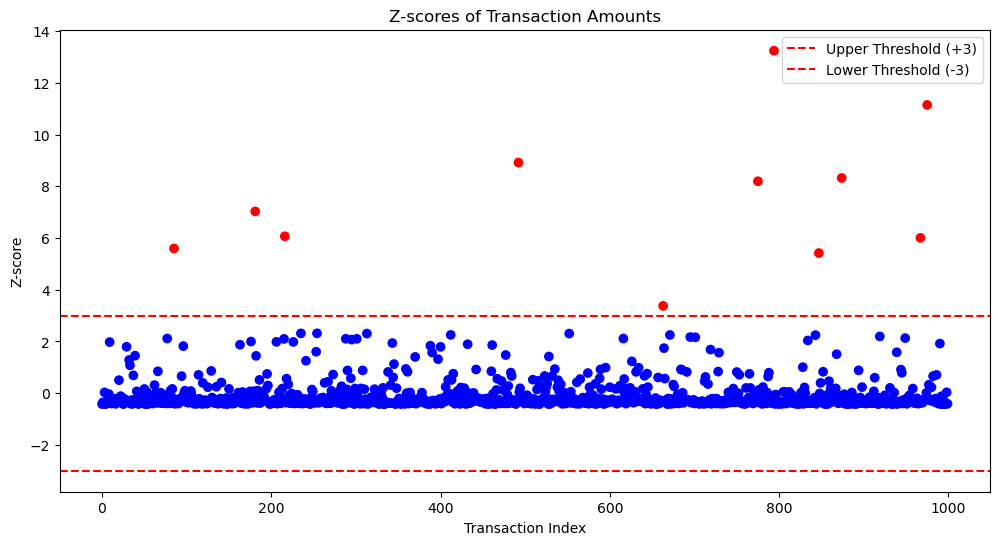

In [98]:
# --- Step 1: Calculate Z-scores for transaction amounts ---
mean = df['amount_inr'].mean()
std = df['amount_inr'].std()
df['Z_score'] = (df['amount_inr'] - mean) / std

# --- Step 2: Define threshold (commonly 3) ---
threshold = 3

# --- Step 3: Plot Z-scores ---
plt.figure(figsize=(12,6))
plt.scatter(df.index, df['Z_score'], c=np.where(df['Z_score'].abs() > threshold, 'red', 'blue'))
plt.axhline(y=threshold, color='r', linestyle='--', label='Upper Threshold (+3)')
plt.axhline(y=-threshold, color='r', linestyle='--', label='Lower Threshold (-3)')
plt.title("Z-scores of Transaction Amounts")
plt.xlabel("Transaction Index")
plt.ylabel("Z-score")
plt.legend()
plt.show()



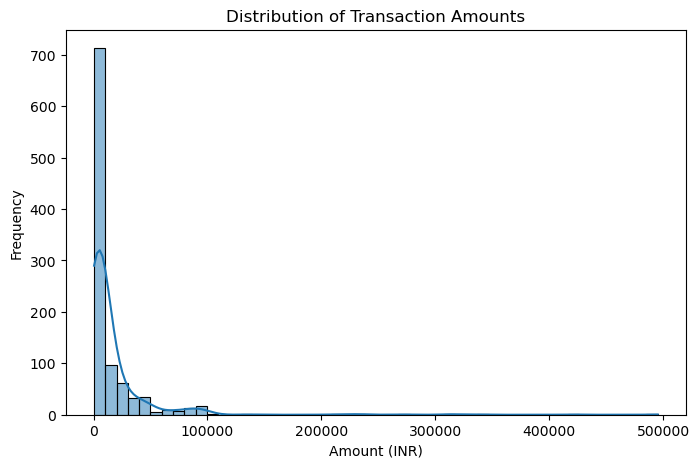

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['amount_inr'], bins=50, kde=True)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Amount (INR)")
plt.ylabel("Frequency")
plt.show()


Statistically unusual users based on transaction amounts:
['txn2562@apl' 'user9480@okicici' 'user2153@ybl' 'acct9871@oksbi'
 'acct2789@okhdfcbank' 'acct1834@ybl' 'mb1533@ybl' 'acct7583@ybl'
 'mb9916@okaxis' 'user4406@apl' 'txn1734@ybl']

Top 10 users with most unusual transactions:
         sender_upi_id  UnusualCount
0         acct1834@ybl             1
1  acct2789@okhdfcbank             1
2         acct7583@ybl             1
3       acct9871@oksbi             1
4           mb1533@ybl             1
5        mb9916@okaxis             1
6          txn1734@ybl             1
7          txn2562@apl             1
8         user2153@ybl             1
9         user4406@apl             1


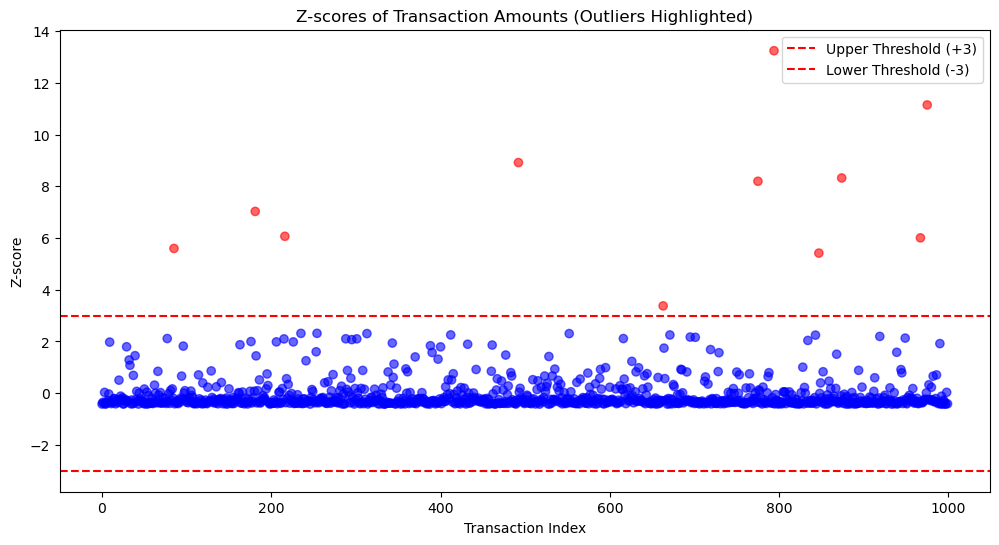

In [100]:
# Which users appear statistically unusual?

# --- Step 1: Calculate Z-scores for transaction amounts ---
df['Z_score'] = (df['amount_inr'] - df['amount_inr'].mean()) / df['amount_inr'].std()

# --- Step 2: Flag unusual transactions (|Z| > 3) ---
df['Unusual'] = np.where(df['Z_score'].abs() > 3, True, False)

# --- Step 3: Identify unusual users (Sender UPI IDs) ---
unusual_users = df[df['Unusual']]['sender_upi_id'].unique()
print("Statistically unusual users based on transaction amounts:")
print(unusual_users)

# --- Step 4: Count unusual transactions per user ---
user_unusual_counts = df[df['Unusual']].groupby('sender_upi_id').size().reset_index(name='UnusualCount')
print("\nTop 10 users with most unusual transactions:")
print(user_unusual_counts.sort_values(by='UnusualCount', ascending=False).head(10))

# --- Step 5: Visualize Z-scores for all transactions ---
plt.figure(figsize=(12,6))
plt.scatter(df.index, df['Z_score'], 
            c=np.where(df['Unusual'], 'red', 'blue'), alpha=0.6)
plt.axhline(y=3, color='r', linestyle='--', label='Upper Threshold (+3)')
plt.axhline(y=-3, color='r', linestyle='--', label='Lower Threshold (-3)')
plt.title("Z-scores of Transaction Amounts (Outliers Highlighted)")
plt.xlabel("Transaction Index")
plt.ylabel("Z-score")
plt.legend()
plt.show()


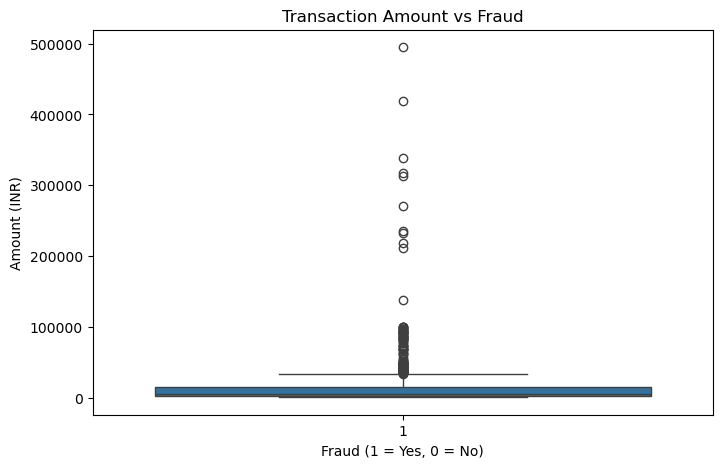

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("upi_fraud_india_dataset.csv")

# Compare fraud vs non-fraud transaction amounts
plt.figure(figsize=(8,5))
sns.boxplot(x='is_fraud', y='amount_inr', data=df)
plt.title("Transaction Amount vs Fraud")
plt.xlabel("Fraud (1 = Yes, 0 = No)")
plt.ylabel("Amount (INR)")
plt.show()

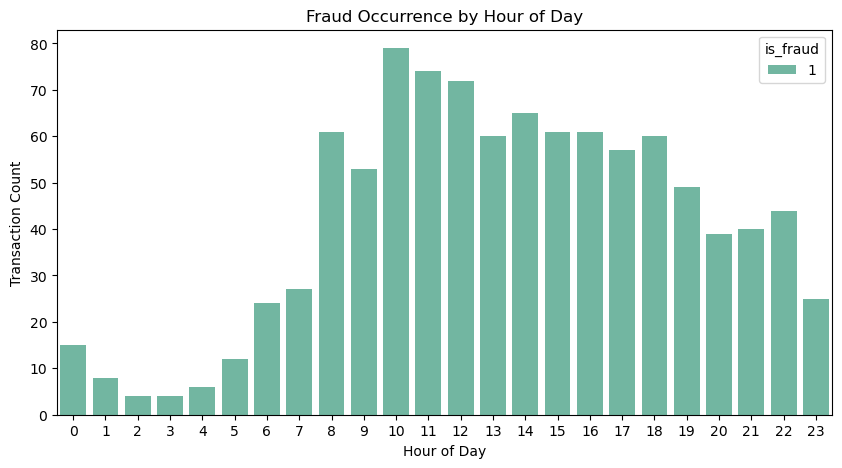

In [21]:
# Convert time column to datetime
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S')

# Extract hour
df['hour'] = df['time'].dt.hour

# Fraud count by hour
plt.figure(figsize=(10,5))
sns.countplot(x='hour', hue='is_fraud', data=df, palette='Set2')
plt.title("Fraud Occurrence by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Transaction Count")
plt.show()


Fraud percentage by device type:
device_type
Android          100.0
Feature Phone    100.0
iOS              100.0
Name: is_fraud, dtype: float64


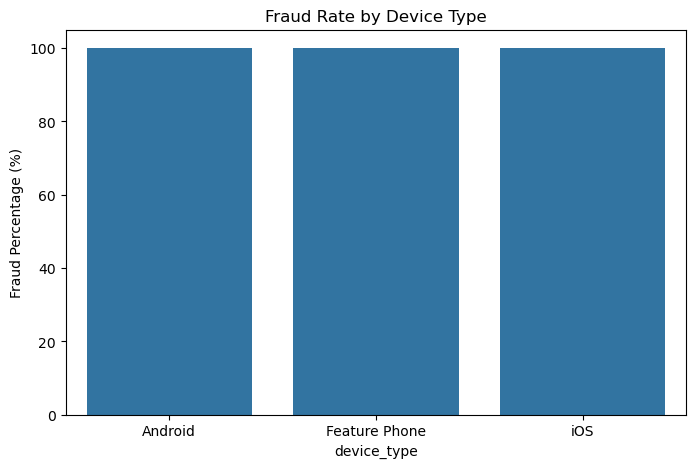

In [23]:
# Fraud rate by device type
device_fraud = df.groupby('device_type')['is_fraud'].mean() * 100

print("Fraud percentage by device type:")
print(device_fraud)

# Bar chart
plt.figure(figsize=(8,5))
sns.barplot(x=device_fraud.index, y=device_fraud.values)
plt.title("Fraud Rate by Device Type")
plt.ylabel("Fraud Percentage (%)")
plt.show()


Fraud percentage by account age (first-time user):
first_time_upi_user
No     100.0
Yes    100.0
Name: is_fraud, dtype: float64


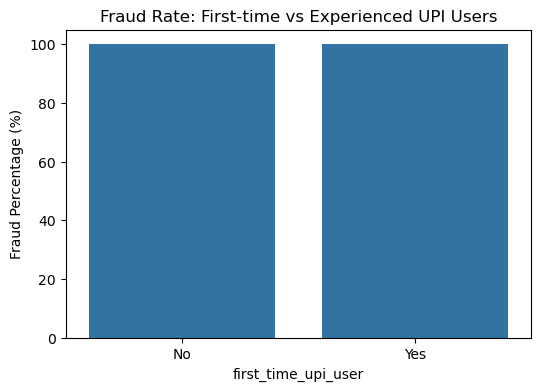

In [25]:
# Fraud rate by first-time UPI user
fraud_account_age = df.groupby('first_time_upi_user')['is_fraud'].mean() * 100

print("Fraud percentage by account age (first-time user):")
print(fraud_account_age)

# Bar chart
plt.figure(figsize=(6,4))
sns.barplot(x=fraud_account_age.index, y=fraud_account_age.values)
plt.title("Fraud Rate: First-time vs Experienced UPI Users")
plt.ylabel("Fraud Percentage (%)")
plt.show()


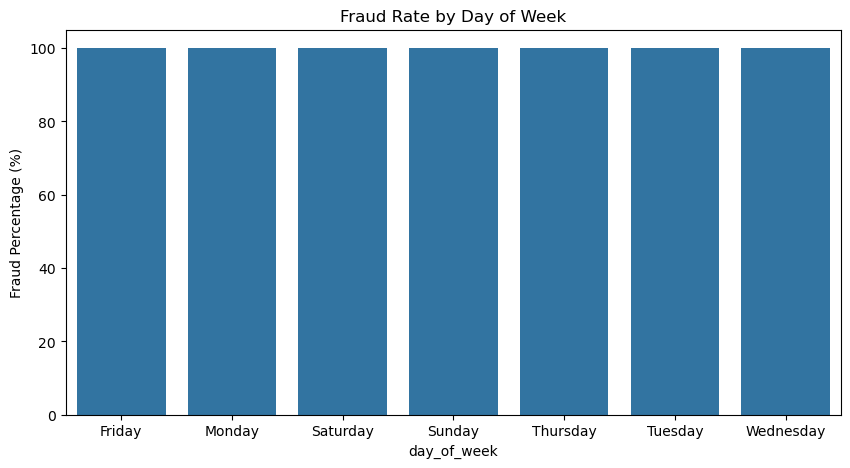

In [29]:
fraud_day = df.groupby('day_of_week')['is_fraud'].mean().reset_index()
fraud_day['fraud_rate'] = fraud_day['is_fraud'] * 100

plt.figure(figsize=(10,5))
sns.barplot(x='day_of_week', y='fraud_rate', data=fraud_day)
plt.title("Fraud Rate by Day of Week")
plt.ylabel("Fraud Percentage (%)")
plt.show()


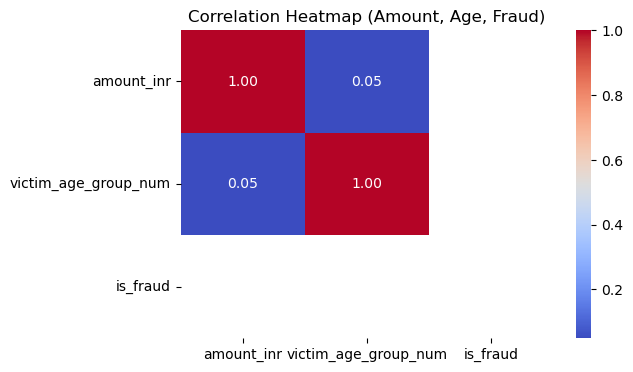

In [43]:
#HEAT MAPS
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("upi_fraud_india_dataset.csv")

# --- 1. Correlation Heatmap (numeric features) ---
# Map age groups to numbers for correlation
age_map = {'18-25':1,'26-35':2,'36-45':3,'46-55':4,'56-65':5,'66+':6}
df['victim_age_group_num'] = df['victim_age_group'].map(age_map)

corr = df[['amount_inr','victim_age_group_num','is_fraud']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Amount, Age, Fraud)")
plt.show()

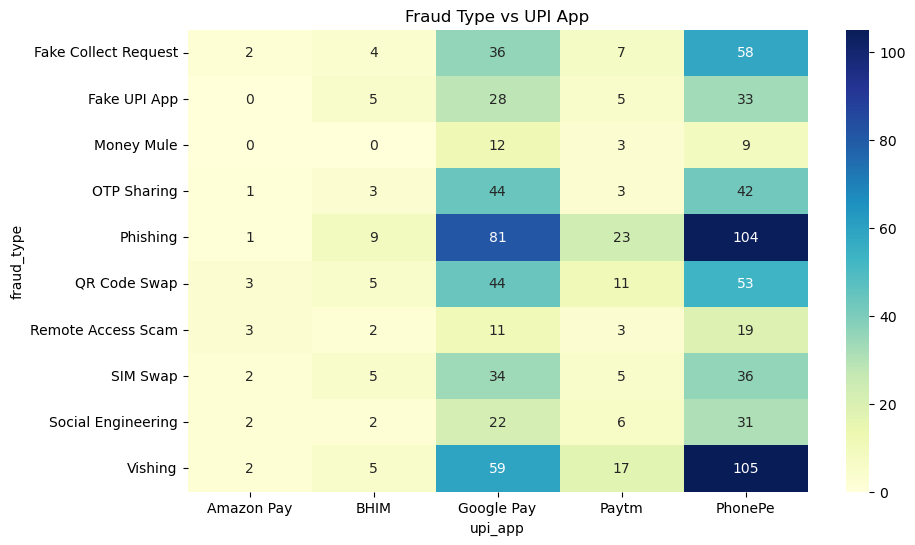

In [45]:
# --- 2. Fraud Type vs UPI App Heatmap ---
fraud_app = pd.crosstab(df['fraud_type'], df['upi_app'])
plt.figure(figsize=(10,6))
sns.heatmap(fraud_app, annot=True, cmap='YlGnBu', fmt="d")
plt.title("Fraud Type vs UPI App")
plt.show()

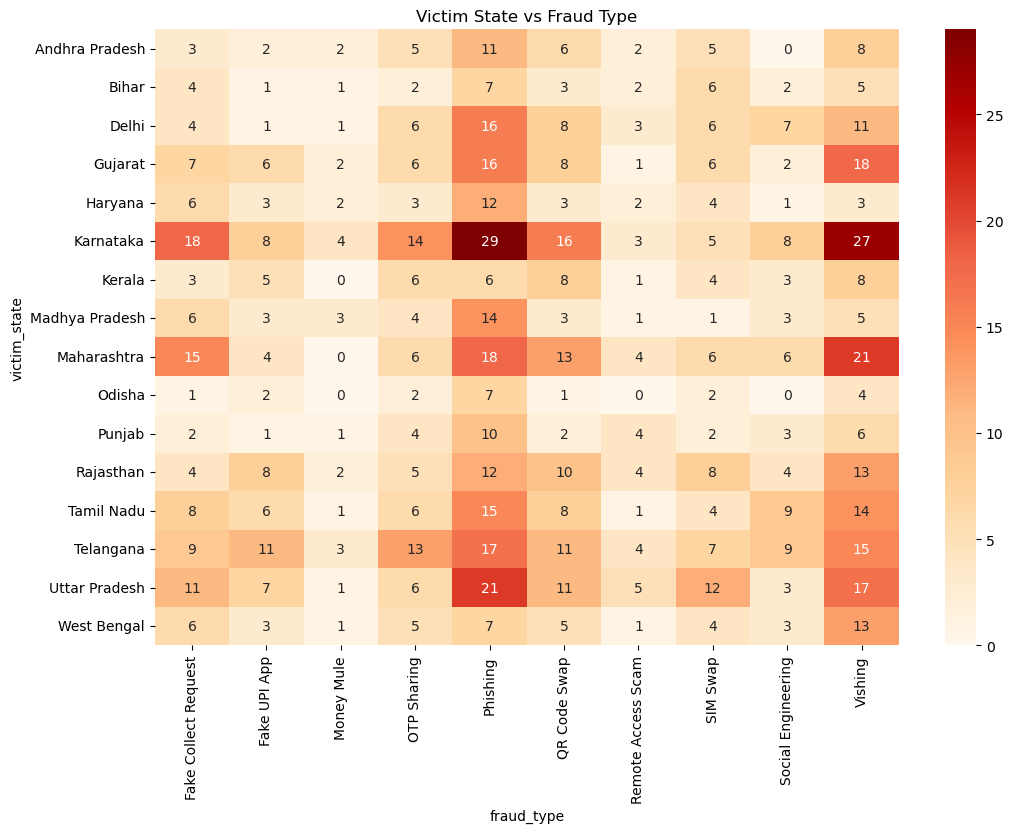

In [47]:
# --- 3. Victim State vs Fraud Type Heatmap ---
state_fraud = pd.crosstab(df['victim_state'], df['fraud_type'])
plt.figure(figsize=(12,8))
sns.heatmap(state_fraud, annot=True, cmap='OrRd', fmt="d")
plt.title("Victim State vs Fraud Type")
plt.show()

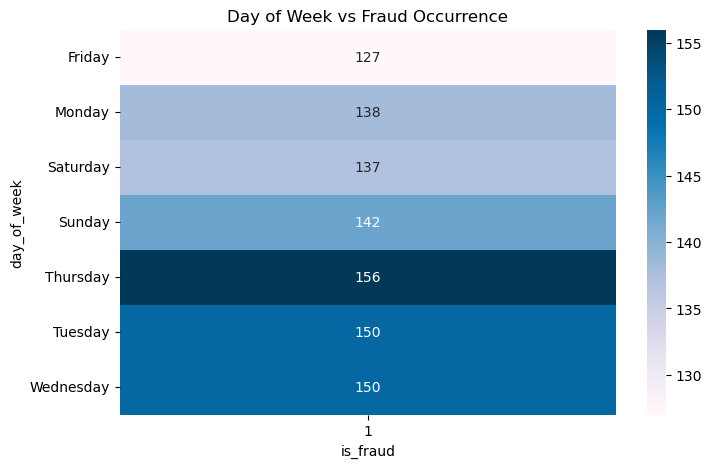

In [49]:
# --- 4. Day of Week vs Fraud Occurrence Heatmap ---
day_fraud = pd.crosstab(df['day_of_week'], df['is_fraud'])
plt.figure(figsize=(8,5))
sns.heatmap(day_fraud, annot=True, cmap='PuBu', fmt="d")
plt.title("Day of Week vs Fraud Occurrence")
plt.show()

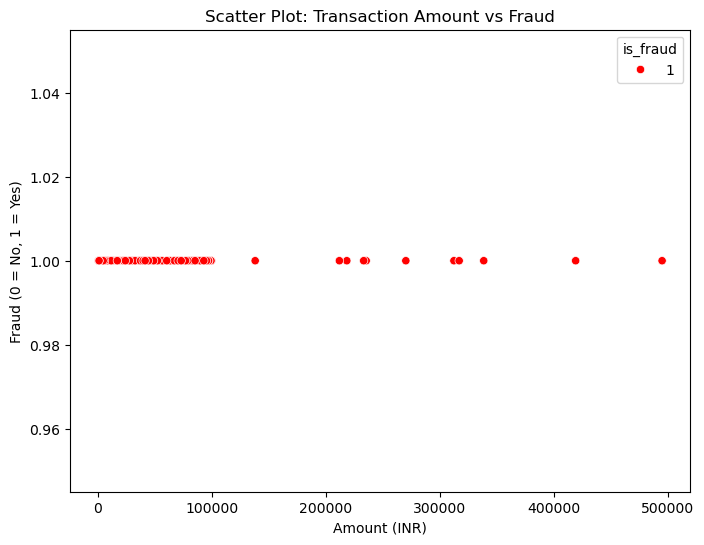

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("upi_fraud_india_dataset.csv")

# Convert time column to datetime for hour extraction
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S')
df['hour'] = df['time'].dt.hour

# --- 1. Transaction Amount vs Fraud ---
plt.figure(figsize=(8,6))
sns.scatterplot(x='amount_inr', y='is_fraud', data=df,
                hue='is_fraud', palette={0:'green',1:'red'})
plt.title("Scatter Plot: Transaction Amount vs Fraud")
plt.xlabel("Amount (INR)")
plt.ylabel("Fraud (0 = No, 1 = Yes)")
plt.show()

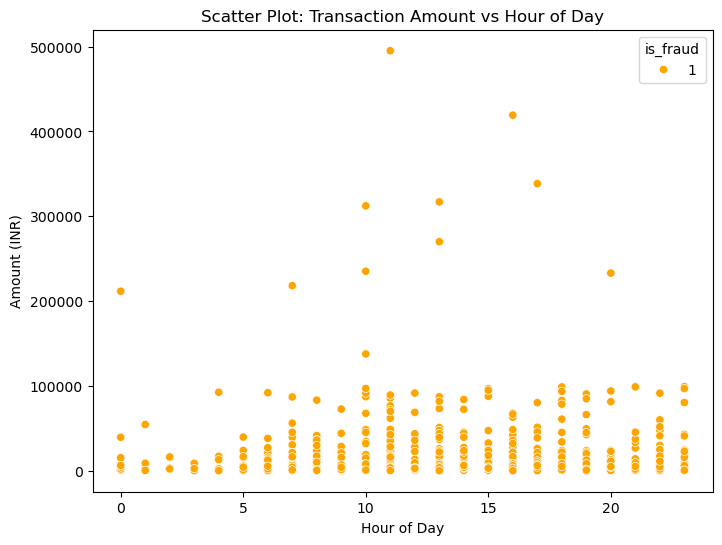

In [53]:
# --- 2. Transaction Amount vs Hour of Day ---
plt.figure(figsize=(8,6))
sns.scatterplot(x='hour', y='amount_inr', data=df,
                hue='is_fraud', palette={0:'blue',1:'orange'})
plt.title("Scatter Plot: Transaction Amount vs Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Amount (INR)")
plt.show()

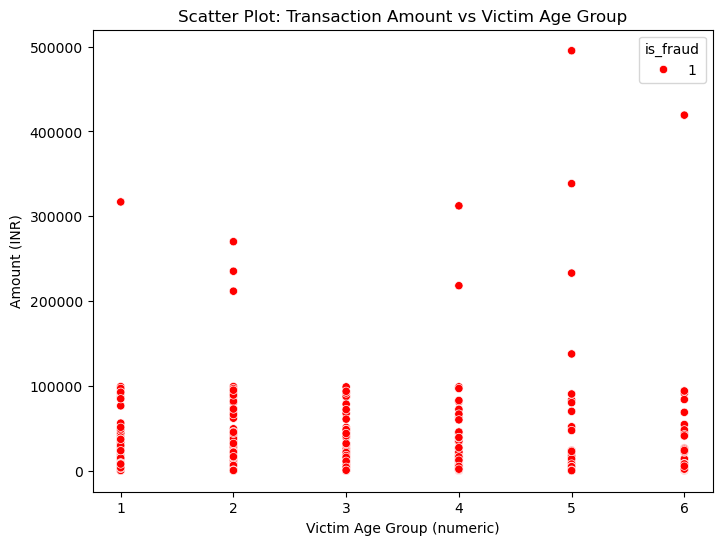

In [55]:
# --- 3. Transaction Amount vs Victim Age Group ---
# Map age groups to numbers for plotting
age_map = {'18-25':1,'26-35':2,'36-45':3,'46-55':4,'56-65':5,'66+':6}
df['victim_age_group_num'] = df['victim_age_group'].map(age_map)

plt.figure(figsize=(8,6))
sns.scatterplot(x='victim_age_group_num', y='amount_inr', data=df,
                hue='is_fraud', palette={0:'purple',1:'red'})
plt.title("Scatter Plot: Transaction Amount vs Victim Age Group")
plt.xlabel("Victim Age Group (numeric)")
plt.ylabel("Amount (INR)")
plt.show()

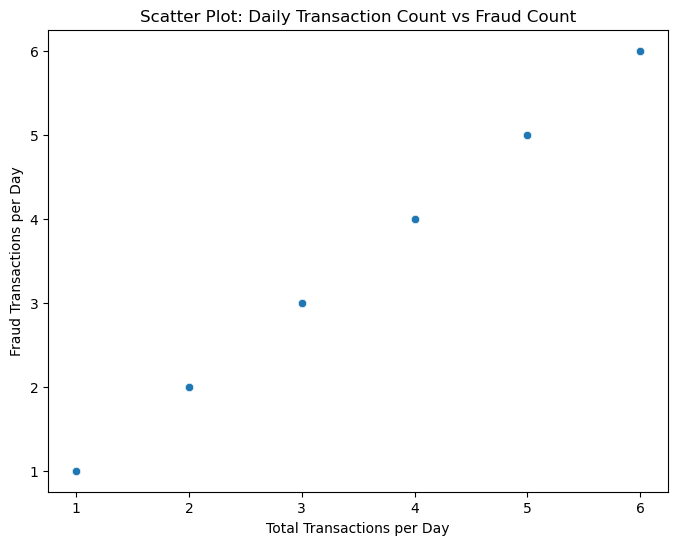

In [57]:
# --- 4. Transaction Frequency vs Fraud (by day) ---
daily_counts = df.groupby(df['date']).size().reset_index(name='transaction_count')
daily_counts['fraud_count'] = df.groupby(df['date'])['is_fraud'].sum().values

plt.figure(figsize=(8,6))
sns.scatterplot(x='transaction_count', y='fraud_count', data=daily_counts)
plt.title("Scatter Plot: Daily Transaction Count vs Fraud Count")
plt.xlabel("Total Transactions per Day")
plt.ylabel("Fraud Transactions per Day")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_22176\2379207237.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='upi_app', y='is_fraud', data=fraud_app, palette='Set2')


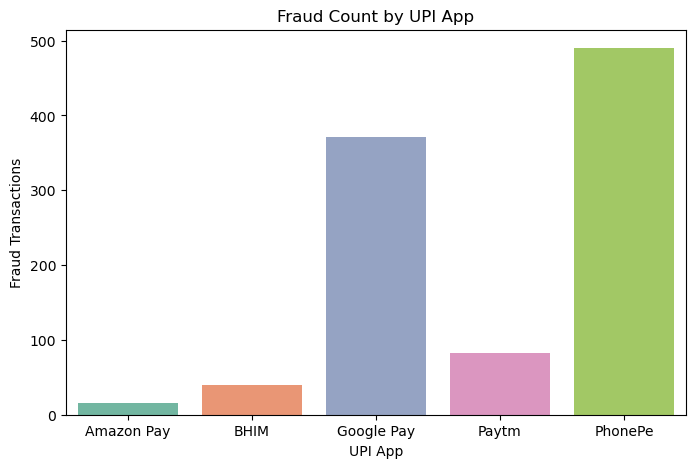

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("upi_fraud_india_dataset.csv")

# --- 1. Fraud Count by UPI App ---
fraud_app = df.groupby('upi_app')['is_fraud'].sum().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='upi_app', y='is_fraud', data=fraud_app, palette='Set2')
plt.title("Fraud Count by UPI App")
plt.ylabel("Fraud Transactions")
plt.xlabel("UPI App")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_22176\2301969387.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='device_type', y='is_fraud', data=fraud_device, palette='Set1')


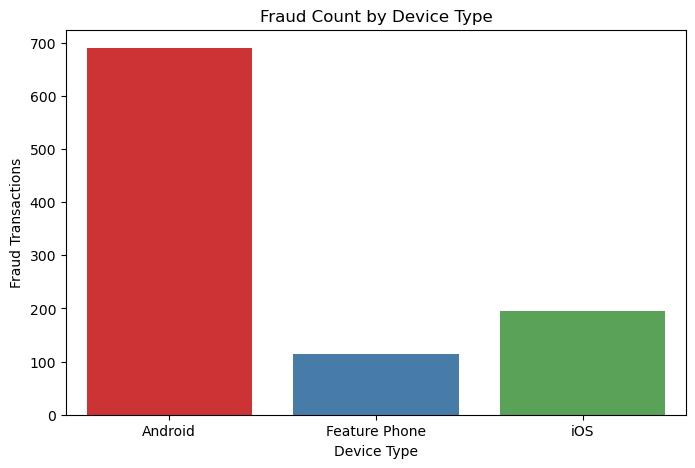

In [61]:
# --- 2. Fraud Count by Device Type ---
fraud_device = df.groupby('device_type')['is_fraud'].sum().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='device_type', y='is_fraud', data=fraud_device, palette='Set1')
plt.title("Fraud Count by Device Type")
plt.ylabel("Fraud Transactions")
plt.xlabel("Device Type")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_22176\2588372495.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='victim_state', y='is_fraud', data=fraud_state, palette='Blues_d')


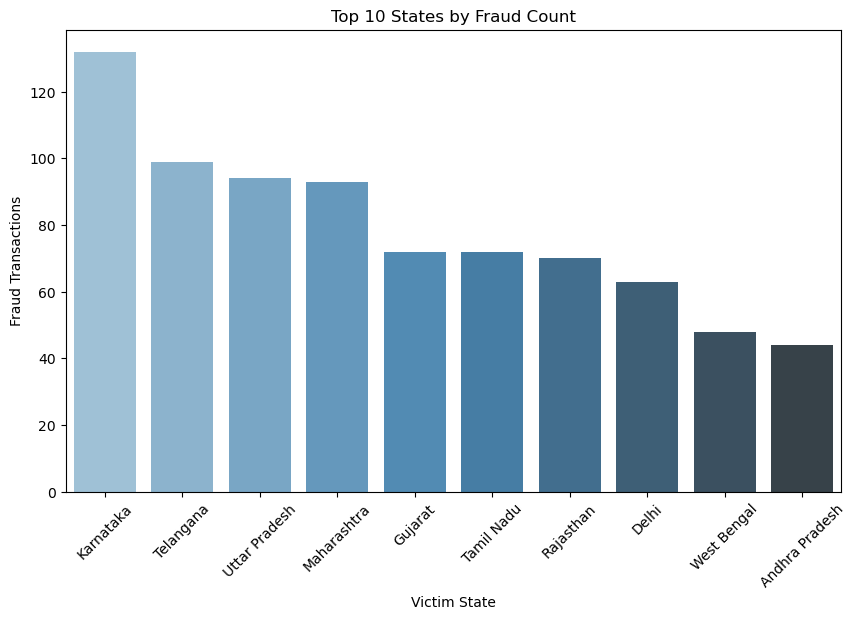

In [63]:
# --- 3. Fraud Count by Victim State (Top 10) ---
fraud_state = df.groupby('victim_state')['is_fraud'].sum().reset_index()
fraud_state = fraud_state.sort_values(by='is_fraud', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='victim_state', y='is_fraud', data=fraud_state, palette='Blues_d')
plt.title("Top 10 States by Fraud Count")
plt.ylabel("Fraud Transactions")
plt.xlabel("Victim State")
plt.xticks(rotation=45)
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_22176\3718257309.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day_of_week', y='is_fraud', data=fraud_day, palette='Oranges')


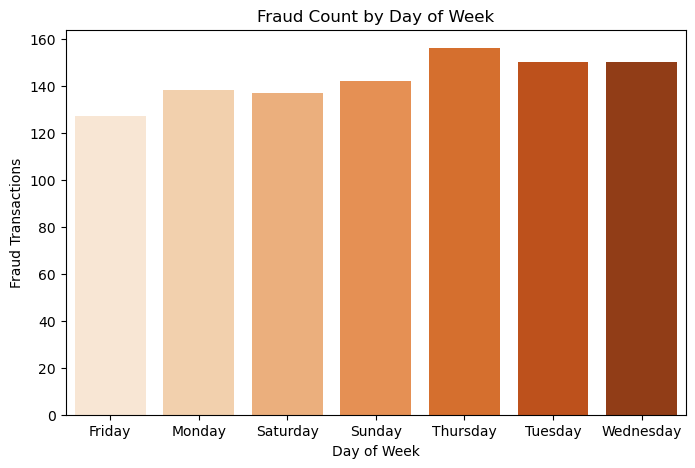

In [65]:
# --- 4. Fraud Count by Day of Week ---
fraud_day = df.groupby('day_of_week')['is_fraud'].sum().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='day_of_week', y='is_fraud', data=fraud_day, palette='Oranges')
plt.title("Fraud Count by Day of Week")
plt.ylabel("Fraud Transactions")
plt.xlabel("Day of Week")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_22176\1929049897.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='fraud_type', y='is_fraud', data=fraud_type, palette='Purples')


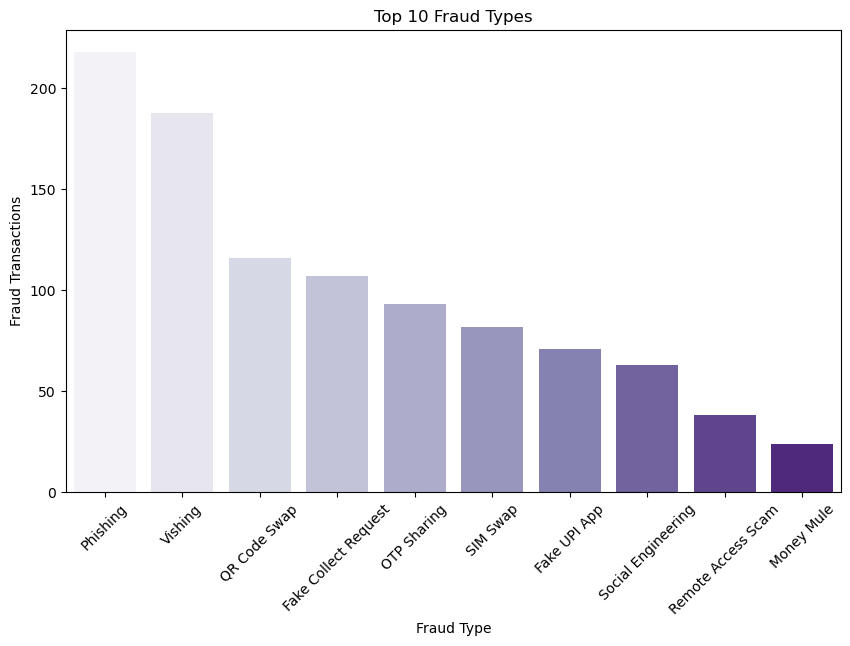

In [67]:
# --- 5. Fraud Count by Fraud Type (Top 10) ---
fraud_type = df.groupby('fraud_type')['is_fraud'].sum().reset_index()
fraud_type = fraud_type.sort_values(by='is_fraud', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='fraud_type', y='is_fraud', data=fraud_type, palette='Purples')
plt.title("Top 10 Fraud Types")
plt.ylabel("Fraud Transactions")
plt.xlabel("Fraud Type")
plt.xticks(rotation=45)
plt.show()

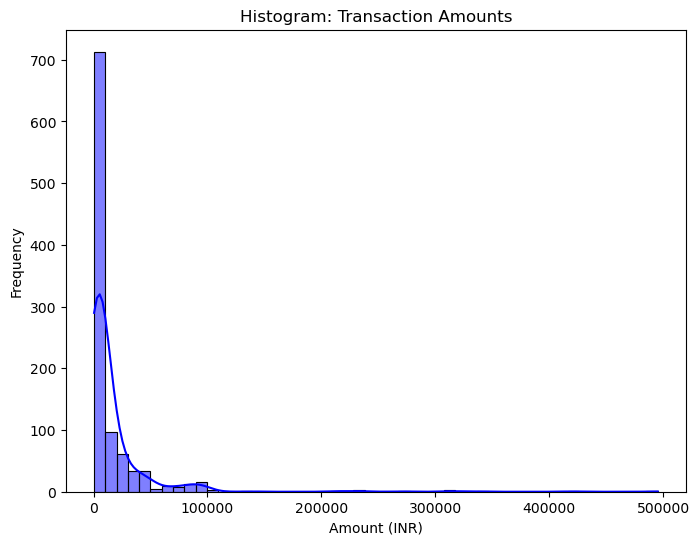

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("upi_fraud_india_dataset.csv")

# --- 1. Histogram of Transaction Amounts ---
plt.figure(figsize=(8,6))
sns.histplot(df['amount_inr'], bins=50, kde=True, color='blue')
plt.title("Histogram: Transaction Amounts")
plt.xlabel("Amount (INR)")
plt.ylabel("Frequency")
plt.show()

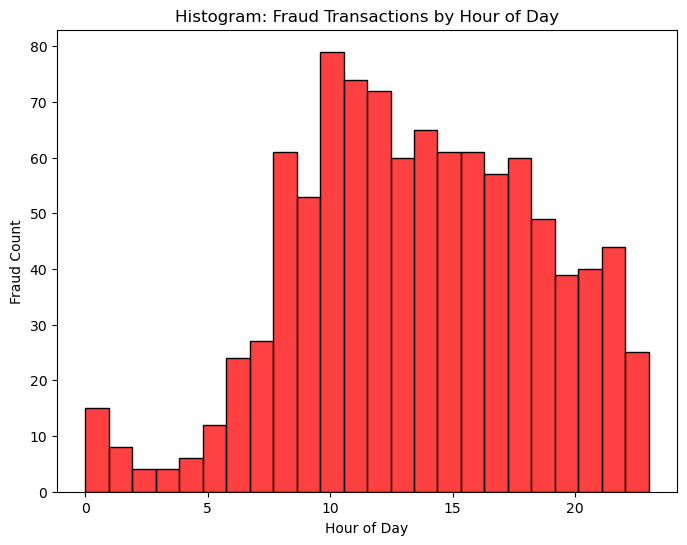

In [73]:
# --- 2. Histogram of Fraud Transactions by Hour ---
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S')
df['hour'] = df['time'].dt.hour

plt.figure(figsize=(8,6))
sns.histplot(df[df['is_fraud']==1]['hour'], bins=24, color='red')
plt.title("Histogram: Fraud Transactions by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Count")
plt.show()

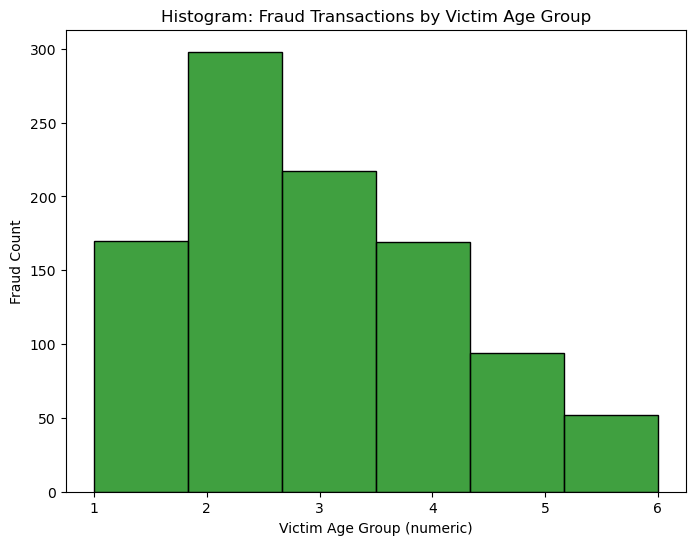

In [75]:
# --- 3. Histogram of Fraud Transactions by Victim Age Group ---
age_map = {'18-25':1,'26-35':2,'36-45':3,'46-55':4,'56-65':5,'66+':6}
df['victim_age_group_num'] = df['victim_age_group'].map(age_map)

plt.figure(figsize=(8,6))
sns.histplot(df[df['is_fraud']==1]['victim_age_group_num'], bins=6, color='green')
plt.title("Histogram: Fraud Transactions by Victim Age Group")
plt.xlabel("Victim Age Group (numeric)")
plt.ylabel("Fraud Count")
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_22176\4187099951.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='report_delay', data=df, order=df['report_delay'].value_counts().index, palette='Set2')


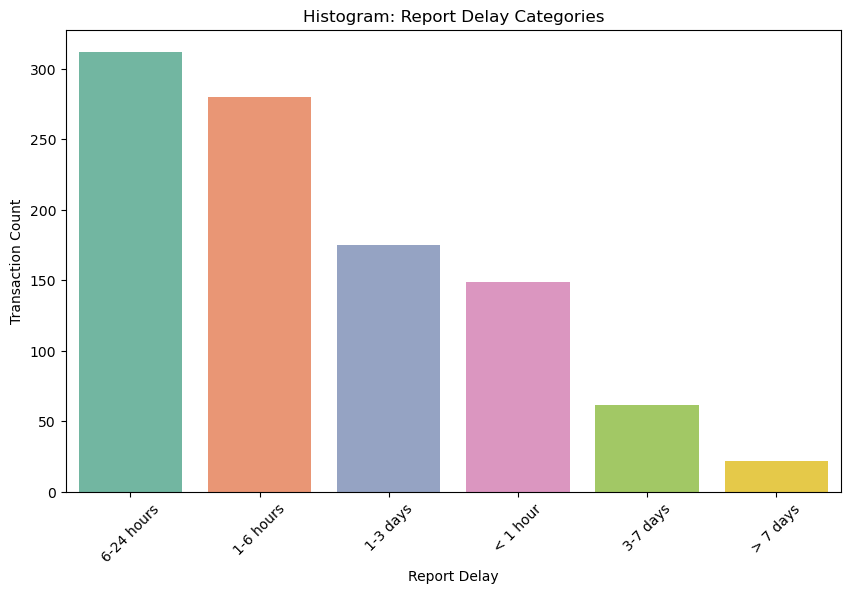

In [77]:
# --- 4. Histogram of Report Delay (categorical converted to counts) ---
plt.figure(figsize=(10,6))
sns.countplot(x='report_delay', data=df, order=df['report_delay'].value_counts().index, palette='Set2')
plt.title("Histogram: Report Delay Categories")
plt.xlabel("Report Delay")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_22176\730558403.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hour', y='is_fraud', data=fraud_by_hour, palette='Reds')


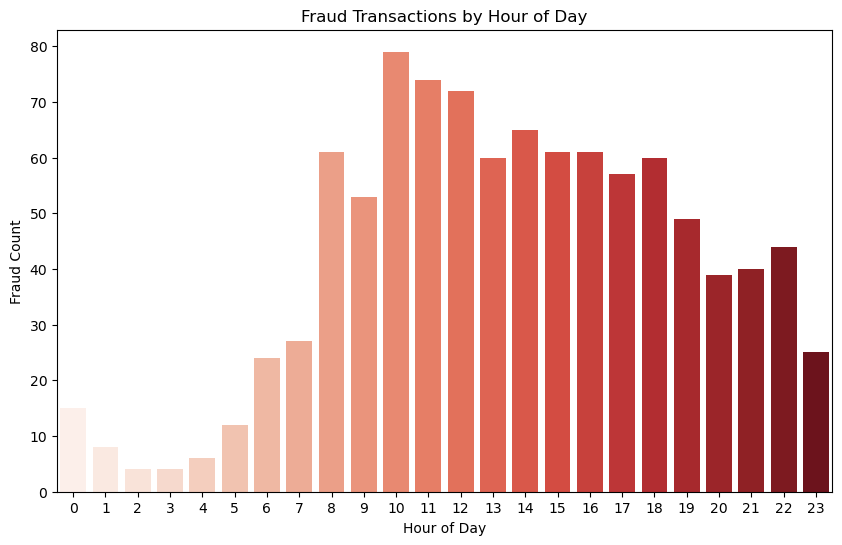

In [80]:
# Are frauds occurring at specific times? 
# Convert time column to datetime
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S')
df['hour'] = df['time'].dt.hour

# Fraud count by hour
fraud_by_hour = df.groupby('hour')['is_fraud'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x='hour', y='is_fraud', data=fraud_by_hour, palette='Reds')
plt.title("Fraud Transactions by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Count")
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_22176\2206525767.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hour', y='is_fraud', data=fraud_by_hour, palette='Reds')


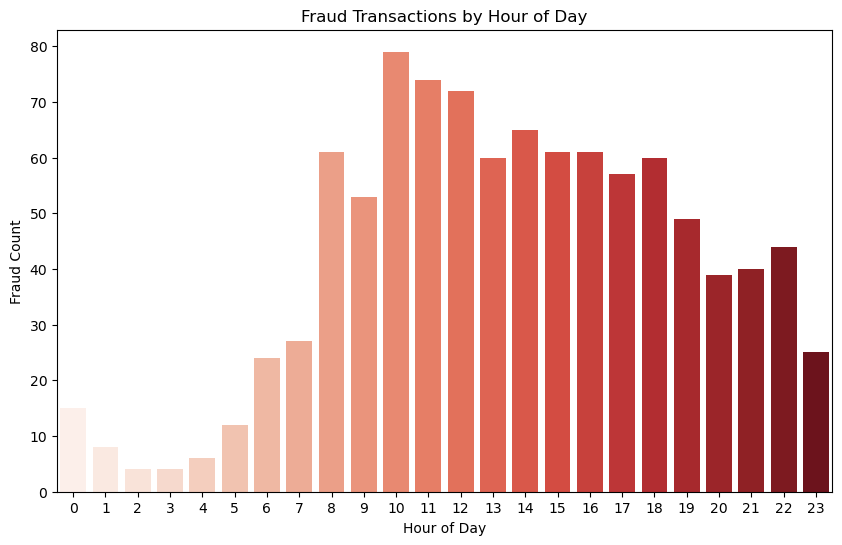

In [82]:
# Do suspicious users change devices often?
# Convert time column to datetime
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S')
df['hour'] = df['time'].dt.hour

# Fraud count by hour
fraud_by_hour = df.groupby('hour')['is_fraud'].sum().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x='hour', y='is_fraud', data=fraud_by_hour, palette='Reds')
plt.title("Fraud Transactions by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Count")
plt.show()


Fraud Rate by User Type:
  first_time_upi_user  is_fraud  fraud_rate
0                  No       1.0       100.0
1                 Yes       1.0       100.0


C:\Users\DELL\AppData\Local\Temp\ipykernel_22176\2414746953.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='first_time_upi_user', y='fraud_rate', data=fraud_by_user_type, palette='Set2')


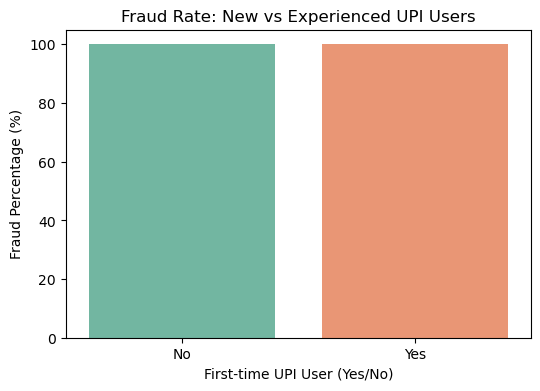

In [84]:
#Are new users more risky?
# Fraud rate by first-time UPI user
fraud_by_user_type = df.groupby('first_time_upi_user')['is_fraud'].mean().reset_index()
fraud_by_user_type['fraud_rate'] = fraud_by_user_type['is_fraud'] * 100

print("Fraud Rate by User Type:")
print(fraud_by_user_type)

# Bar chart visualization
plt.figure(figsize=(6,4))
sns.barplot(x='first_time_upi_user', y='fraud_rate', data=fraud_by_user_type, palette='Set2')
plt.title("Fraud Rate: New vs Experienced UPI Users")
plt.xlabel("First-time UPI User (Yes/No)")
plt.ylabel("Fraud Percentage (%)")
plt.show()


In [ ]:
import pandas as pd
from scipy.stats import ttest_ind

# Load dataset
df = pd.read_csv("upi_fraud_india_dataset.csv")

# Split into fraud vs non-fraud groups
fraud_amounts = df[df['is_fraud'] == 1]['amount_inr']
nonfraud_amounts = df[df['is_fraud'] == 0]['amount_inr']

# Perform independent t-test
t_stat, p_value = ttest_ind(fraud_amounts, nonfraud_amounts, equal_var=False)

print("T-Test Results:")
print("t-statistic:", t_stat)
print("p-value:", p_value)

T-Test Results:
t-statistic: nan
p-value: nan


In [33]:
from scipy.stats import ttest_ind

vishing = df[df['fraud_type'] == 'Vishing']['amount_inr']
phishing = df[df['fraud_type'] == 'Phishing']['amount_inr']

if len(vishing) > 1 and len(phishing) > 1:
    t_stat, p_value = ttest_ind(vishing, phishing, equal_var=False)
    print("T-Test Results (Vishing vs Phishing):")
    print("t-statistic:", t_stat)
    print("p-value:", p_value)
else:
    print("Not enough data in one of the groups.")


T-Test Results (Vishing vs Phishing):
t-statistic: 1.3060903742208922
p-value: 0.1926241558869439


In [35]:
from scipy.stats import f_oneway

# Group transaction amounts by UPI app
apps = df['upi_app'].unique()
groups = [df[df['upi_app'] == app]['amount_inr'] for app in apps]

# Perform ANOVA
f_stat, p_value = f_oneway(*groups)

print("ANOVA Results:")
print("F-statistic:", f_stat)
print("p-value:", p_value)


ANOVA Results:
F-statistic: 1.9097845193797738
p-value: 0.10663396416976939


In [37]:
import scipy.stats as stats

# Create contingency table
contingency = pd.crosstab(df['device_type'], df['is_fraud'])

# Perform Chi-Square test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print("Chi-Square Test Results:")
print("Chi2 statistic:", chi2)
print("p-value:", p_value)


Chi-Square Test Results:
Chi2 statistic: 0.0
p-value: 1.0
